In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker
import matplotlib.dates as mdates
import numpy as np

import intake

import sys
# sys.path.append("/work/mh1498/m301248/TCO_data/COARE-algorithm/Python/COARE3.5/") 

# sys.path.append("/work/mh1498/m301248/TCO_data/BCO_observational/mass_fluxes_profiles/yk22_mass_fluxes.py")
# import yk22_mass_fluxes

import metpy

# import meteo


import pandas as pd
from IPython.display import display, HTML


## working local
local_path = {
              "joanne4": "/Users/alessandrostorer/Desktop/PhD/1st_yy/work/datasets/dropsondes_34/EUREC4A_JOANNE_Dropsonde-RD41_Level_4_v2.0.0.nc",
              "joanne3": "/Users/alessandrostorer/Desktop/PhD/1st_yy/work/datasets/dropsondes_34/EUREC4A_JOANNE_Dropsonde-RD41_Level_3_v2.0.0.nc",
              "beach4": "/Users/alessandrostorer/Desktop/PhD/1st_yy/work/datasets/dropsondes_34/ORCESTRA_BEACH_level_4.nc",
              "beach3":  "/Users/alessandrostorer/Desktop/PhD/1st_yy/work/datasets/dropsondes_34/ORCESTRA_BEACH_level_3.nc"
              }

In [2]:
## constants I always need
Lv = 2.5e6  # J/kg
cp = 1004.7 # J/kg K

Rd = 287.   # J / kg K

In [3]:
## local access
beach4  = xr.open_dataset(local_path["beach4"])  # level 4
beach3 = xr.open_dataset(local_path["beach3"])  # level 3

In [4]:
beach4 = beach4.swap_dims({"sonde": "sonde_id"})
beach3 = beach3.swap_dims({"sonde": "sonde_id"})
common = np.intersect1d(beach3.sonde_id, beach4.sonde_id)

beach3 = beach3.sel(sonde_id=common)
beach4 = beach4.sel(sonde_id=common)

In [5]:
beach4

<xarray.Dataset> Size: 116MB
Dimensions:                   (circle: 89, altitude: 1460, sonde_id: 1058)
Coordinates:
    circle_lat                (circle) float32 356B ...
    circle_lon                (circle) float32 356B ...
    circle_time               (circle) datetime64[ns] 712B ...
    sondes_per_circle         (circle) int64 712B ...
  * altitude                  (altitude) float64 12kB 0.0 10.0 ... 1.459e+04
  * sonde_id                  (sonde_id) <U8 34kB '000f256c' ... 'ffdd9f57'
    launch_time               (sonde_id) datetime64[ns] 8kB ...
Dimensions without coordinates: circle
Data variables: (12/72)
    circle_altitude           (circle) float32 356B ...
    circle_id                 (circle) <U19 7kB ...
    circle_radius             (circle) float32 356B ...
    div                       (circle, altitude) float32 520kB ...
    div_sonde_relevance       (sonde_id, altitude) float32 6MB ...
    div_std_error             (circle, altitude) float32 520kB ...
    ...                        ...
    wspd_mean                 (circle, altitude) float32 520kB ...
    wvel                      (circle, altitude) float32 520kB ...
    wvel_sonde_relevance      (sonde_id, altitude) float32 6MB ...
    wvel_std_error            (circle, altitude) float32 520kB ...
    x                         (sonde_id, altitude) float32 6MB ...
    y                         (sonde_id, altitude) float32 6MB ...
Attributes: (12/16)
    title:             BEACH dropsonde dataset (Level 4)
    source:            dropsondes
    creator_name:      Helene Gloeckner, Theresa Mieslinger, Nina Robbins
    creator_email:     helene.gloeckner@mpimet.mpg.de, theresa.mieslinger@mpi...
    creator_id:        https://orcid.org/0009-0007-2741-9724, https://orcid.o...
    project:           ORCESTRA, PERCUSION, MAESTRO
    ...                ...
    license:           CC-BY-4.0
    featureType:       trajectoryProfile
    keywords:          ORCESTRA, BEACH, Sounding, Dropsondes, Tropics, Atmosp...
    summary:           This dataset is the Level 4 BEACH dataset. It contains...
    processing_level:  4
    history:           Level 1 ASPEN processing with Aspen V4.0.4 \nLevel 2 q...

#### check vertical distribution of mean wind speed and gradients

In [6]:
lon_condition = (beach4.circle_lon < -40)
beach4w = beach4.sel(altitude=slice(0,7000)).where(lon_condition, drop=True)

In [7]:
beach4w

<xarray.Dataset> Size: 2GB
Dimensions:                   (circle: 46, altitude: 701, sonde_id: 1058)
Coordinates:
    circle_lat                (circle) float32 184B 12.0 7.001 ... 12.17 10.76
    circle_lon                (circle) float32 184B -50.47 -48.62 ... -56.91
    circle_time               (circle) datetime64[ns] 368B 2024-09-06T15:51:1...
    sondes_per_circle         (circle) int64 368B 12 14 14 13 12 ... 14 14 12 13
  * altitude                  (altitude) float64 6kB 0.0 10.0 ... 6.99e+03 7e+03
  * sonde_id                  (sonde_id) <U8 34kB '000f256c' ... 'ffdd9f57'
    launch_time               (sonde_id) datetime64[ns] 8kB ...
Dimensions without coordinates: circle
Data variables: (12/72)
    circle_altitude           (circle) float32 184B 1.444e+04 ... 1.441e+04
    circle_id                 (circle) object 368B 'HALO-20240906a_67f6' ... ...
    circle_radius             (circle) float32 184B 1.331e+05 ... 1.331e+05
    div                       (circle, altitude) float32 129kB 7.753e-06 ... ...
    div_sonde_relevance       (sonde_id, altitude, circle) float32 136MB 1.58...
    div_std_error             (circle, altitude) float32 129kB 5.289e-06 ... ...
    ...                        ...
    wspd_mean                 (circle, altitude) float32 129kB nan ... 7.978
    wvel                      (circle, altitude) float32 129kB -0.0 ... 0.006937
    wvel_sonde_relevance      (sonde_id, altitude, circle) float32 136MB 0.0 ...
    wvel_std_error            (circle, altitude) float32 129kB nan ... 0.0008493
    x                         (sonde_id, altitude, circle) float32 136MB 4.85...
    y                         (sonde_id, altitude, circle) float32 136MB 1.26...
Attributes: (12/16)
    title:             BEACH dropsonde dataset (Level 4)
    source:            dropsondes
    creator_name:      Helene Gloeckner, Theresa Mieslinger, Nina Robbins
    creator_email:     helene.gloeckner@mpimet.mpg.de, theresa.mieslinger@mpi...
    creator_id:        https://orcid.org/0009-0007-2741-9724, https://orcid.o...
    project:           ORCESTRA, PERCUSION, MAESTRO
    ...                ...
    license:           CC-BY-4.0
    featureType:       trajectoryProfile
    keywords:          ORCESTRA, BEACH, Sounding, Dropsondes, Tropics, Atmosp...
    summary:           This dataset is the Level 4 BEACH dataset. It contains...
    processing_level:  4
    history:           Level 1 ASPEN processing with Aspen V4.0.4 \nLevel 2 q...

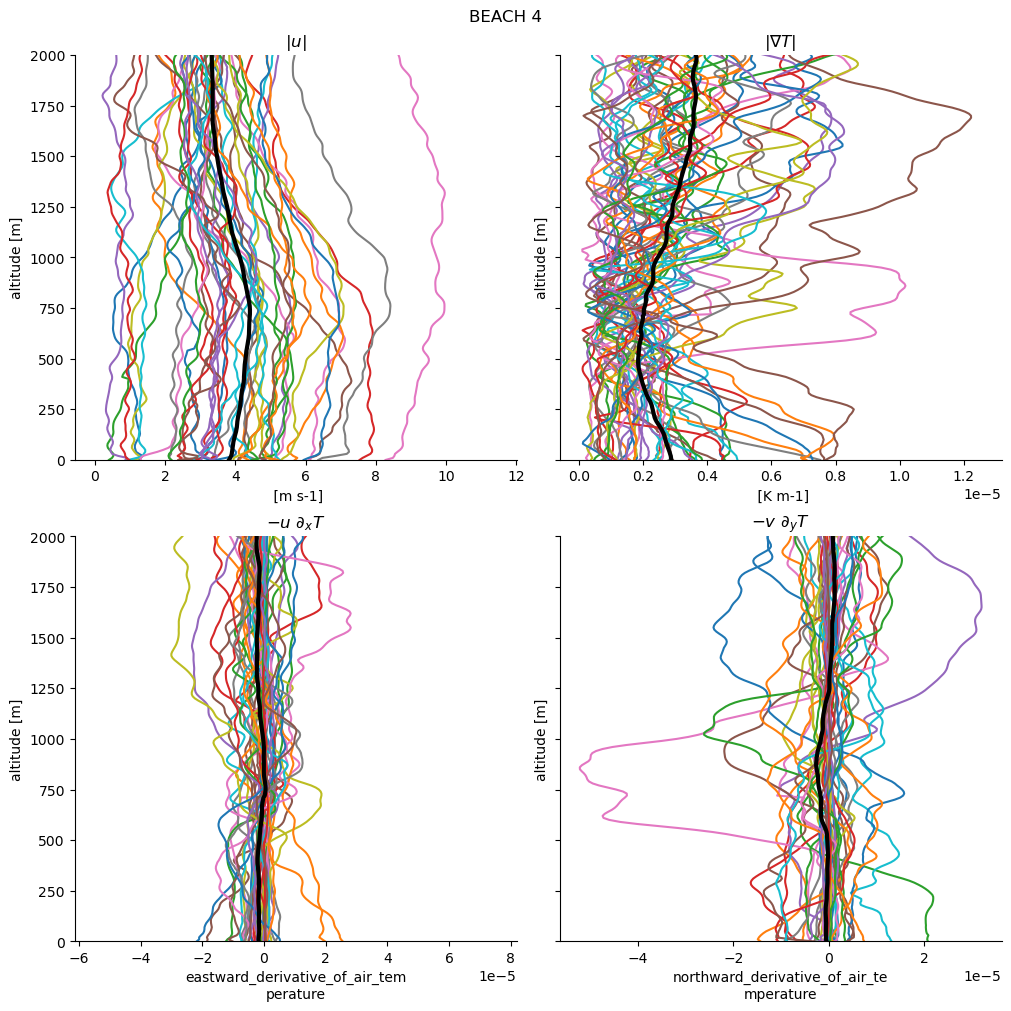

In [8]:
fig, ax = plt.subplots(2, 2, figsize=(10,10), sharey=True, constrained_layout=True)
fig.suptitle("BEACH 4")
ax=ax.flatten()
ax[0].set_ylim([0,2000])

((beach4w.u_mean**2 + beach4w.v_mean**2)**0.5).plot.line(ax=ax[0], y="altitude", add_legend=False)
((beach4w.u_mean**2 + beach4w.v_mean**2)**0.5).mean(dim="circle").plot.line(ax=ax[0], y="altitude", color="k", linewidth=3, add_legend=False)
ax[0].set_title(r"$|u|$")

((beach4w.ta_dtadx**2 + beach4w.ta_dtady**2)**0.5).plot.line(ax=ax[1], y="altitude", add_legend=False)
((beach4w.ta_dtadx**2 + beach4w.ta_dtady**2)**0.5).mean(dim="circle").plot.line(ax=ax[1], y="altitude", color="k", linewidth=3, add_legend=False)
ax[1].set_title(r"$|\nabla T|$")




(- beach4w.u_mean * beach4w.ta_dtadx).plot.line(ax=ax[2], y="altitude", add_legend=False)
(- beach4w.u_mean * beach4w.ta_dtadx).mean(dim="circle").plot.line(ax=ax[2], y="altitude", color="k", linewidth=3, add_legend=False)
ax[2].set_title(r"$-u~\partial_x T$")

(- beach4w.v_mean * beach4w.ta_dtady).plot.line(ax=ax[3], y="altitude", add_legend=False)
(- beach4w.v_mean * beach4w.ta_dtady).mean(dim="circle").plot.line(ax=ax[3], y="altitude", color="k", linewidth=3, add_legend=False)
ax[3].set_title(r"$-v~\partial_y T$")


for x in ax:
    for spine in ["right", 'top']:
        x.spines[spine].set_visible(False)

plt.show()

In [9]:
## local access
joanne4  = xr.open_dataset(local_path["joanne4"])  # level 4
joanne3 = xr.open_dataset(local_path["joanne3"])  # level 3


halo = joanne4.platform_id == "HALO"
joanne4 = joanne4.sel(alt=slice(0,7000)).where(halo, drop=True)

halo = joanne3.platform_id == "HALO"
joanne3 = joanne3.sel(alt=slice(0,7000)).where(halo, drop=True)

In [10]:
joanne3

<xarray.Dataset> Size: 57MB
Dimensions:            (sonde_id: 810, alt: 701, nv: 2)
Coordinates:
  * sonde_id           (sonde_id) <U13 42kB 'HALO-0119_s02' ... 'HALO-0218_s01'
    launch_time        (sonde_id) datetime64[ns] 6kB 2020-01-19T16:55:14 ... ...
  * alt                (alt) int16 1kB 0 10 20 30 40 ... 6970 6980 6990 7000
    interpolated_time  (sonde_id, alt) datetime64[ns] 5MB ...
    lat                (sonde_id, alt) float32 2MB ...
    lon                (sonde_id, alt) float32 2MB ...
Dimensions without coordinates: nv
Data variables: (12/23)
    p                  (sonde_id, alt) float32 2MB nan 1.013e+05 ... 4.313e+04
    ta                 (sonde_id, alt) float32 2MB nan 299.0 ... 257.5 257.5
    rh                 (sonde_id, alt) float32 2MB nan 0.7669 ... 0.1173 0.1154
    wspd               (sonde_id, alt) float32 2MB nan 9.681 ... 5.539 5.482
    wdir               (sonde_id, alt) float32 2MB nan 67.17 ... 357.1 356.0
    u                  (sonde_id, alt) float32 2MB nan -8.922 ... 0.2827 0.3828
    ...                 ...
    N_gps              (sonde_id, alt) float32 2MB nan 2.0 2.0 ... 1.0 nan 1.0
    m_p                (sonde_id, alt) float32 2MB nan 2.0 2.0 ... 1.0 nan 1.0
    m_ta               (sonde_id, alt) float32 2MB nan 2.0 2.0 ... 1.0 nan 1.0
    m_rh               (sonde_id, alt) float32 2MB nan 2.0 2.0 ... 1.0 nan 1.0
    m_gps              (sonde_id, alt) float32 2MB nan 2.0 2.0 ... 1.0 nan 1.0
    alt_bnds           (alt, nv, sonde_id) float64 9MB -5.0 -5.0 ... 7.005e+03
Attributes: (12/16)
    title:                   EUREC4A JOANNE Level-3
    doi:                     10.25326/246
    created with:            run_joanne.py doi:10.5281/zenodo.5521192
    Conventions:             CF-1.8
    campaign_id:             EUREC4A
    project_id:              JOANNE
    ...                      ...
    JOANNE_version:          2.0.0
    author:                  Geet George
    author_email:            geet.george@mpimet.mpg.de
    featureType:             trajectory
    reference:               George et al., JOANNE : Joint dropsonde Observat...
    creation_time:           2021-09-22 14:35:24.817595 UTC

In [11]:
joanne4

<xarray.Dataset> Size: 6MB
Dimensions:          (circle: 71, alt: 701, sounding: 13)
Coordinates:
  * circle           (circle) int64 568B 14 15 16 17 18 19 ... 79 80 81 82 83 84
    circle_lon       (circle) float32 284B -57.86 -57.7 -57.71 ... -57.67 -57.65
    circle_lat       (circle) float32 284B 13.27 13.27 13.28 ... 13.33 13.33
    circle_time      (circle) datetime64[ns] 568B 2020-01-19T17:53:57.800000 ...
    segment_id       (circle) <U12 3kB 'HALO-0119_c1' ... 'HALO-0215_c6'
  * alt              (alt) int16 1kB 0 10 20 30 40 ... 6960 6970 6980 6990 7000
  * sounding         (sounding) int64 104B 0 1 2 3 4 5 6 7 8 9 10 11 12
Data variables: (12/36)
    platform_id      (circle) object 568B 'HALO' 'HALO' 'HALO' ... 'HALO' 'HALO'
    flight_altitude  (circle) float32 284B 1.026e+04 1.029e+04 ... 1.119e+04
    circle_diameter  (circle) float32 284B 1.867e+05 2.225e+05 ... 2.236e+05
    u                (circle, alt) float32 199kB nan -8.829 ... 10.53 10.54
    dudx             (circle, alt) float32 199kB nan 8.21e-06 ... 1.218e-05
    dudy             (circle, alt) float32 199kB nan 6.836e-06 ... -1.307e-05
    ...               ...
    se_dtadx         (circle, alt) float32 199kB nan -0.0 ... 1.407e-06 1.39e-06
    se_dtady         (circle, alt) float32 199kB nan -0.0 ... 1.573e-06
    se_D             (circle, alt) float32 199kB nan 6.747e-06 ... 1.161e-05
    se_vor           (circle, alt) float32 199kB nan 6.725e-06 ... 1.07e-05
    se_W             (circle, alt) float32 199kB 0.0 6.747e-06 ... 0.007306
    omega            (circle, alt) float32 199kB nan 0.002026 ... -0.007611
Attributes: (12/16)
    title:                   EUREC4A JOANNE Level-4
    doi:                     10.25326/246
    created with:            run_joanne.py doi:10.5281/zenodo.5521192
    Conventions:             CF-1.8
    campaign_id:             EUREC4A
    project_id:              JOANNE
    ...                      ...
    JOANNE_version:          2.0.0
    author:                  Geet George
    author_email:            geet.george@mpimet.mpg.de
    featureType:             trajectory
    reference:               George et al., JOANNE : Joint dropsonde Observat...
    creation_time:           2021-09-22 15:58:46.773760 UTC

### JOANNE's circle time series of temperature

how come Albright et al. '22 find a campaign-mean positive time dependency?

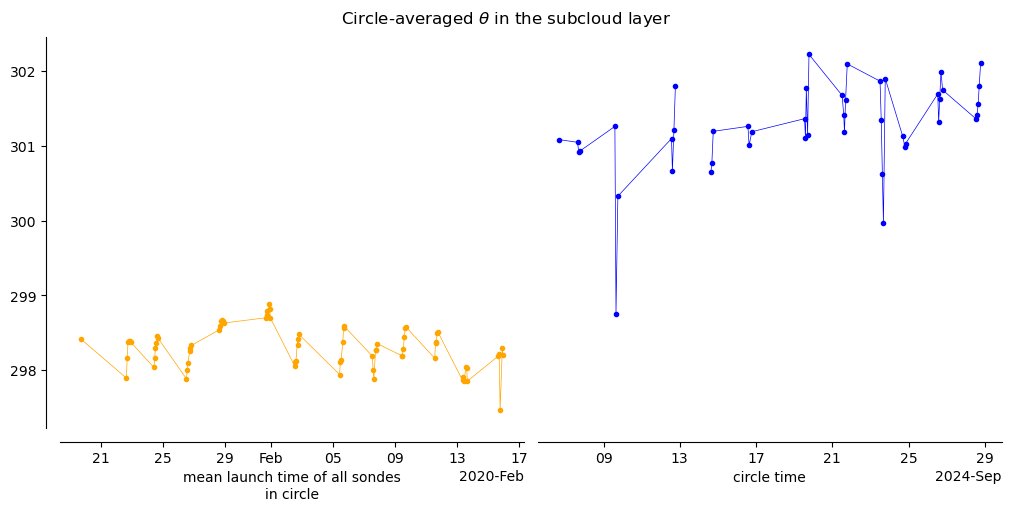

In [40]:
fig, ax = plt.subplots(1, 2, figsize=(10,5), sharey=True, constrained_layout=True)
fig.suptitle(r"Circle-averaged $\theta$ in the subcloud layer")

theta = (joanne4.ta * (100000. / joanne4.p)**(0.287)).sel(alt=slice(0,500))
theta.mean(dim="alt").plot(ax=ax[0], x="circle_time", marker='.', linewidth=0.5, color="orange")

west = beach4.circle_lon < -40.
beach4.theta_mean.sel(altitude=slice(0,500)).where(west, drop=True).mean(dim="altitude").plot(ax=ax[1], x="circle_time", marker='.', linewidth=0.5, color="blue")


ax[1].yaxis.set_visible(False)
ax[1].spines["left"].set_visible(False)

for x in ax:
    for spine in ['top', 'right']:
        x.spines[spine].set_visible(False)

    for spine in ["left", 'bottom']:
        x.spines[spine].set_position(("outward", 10))

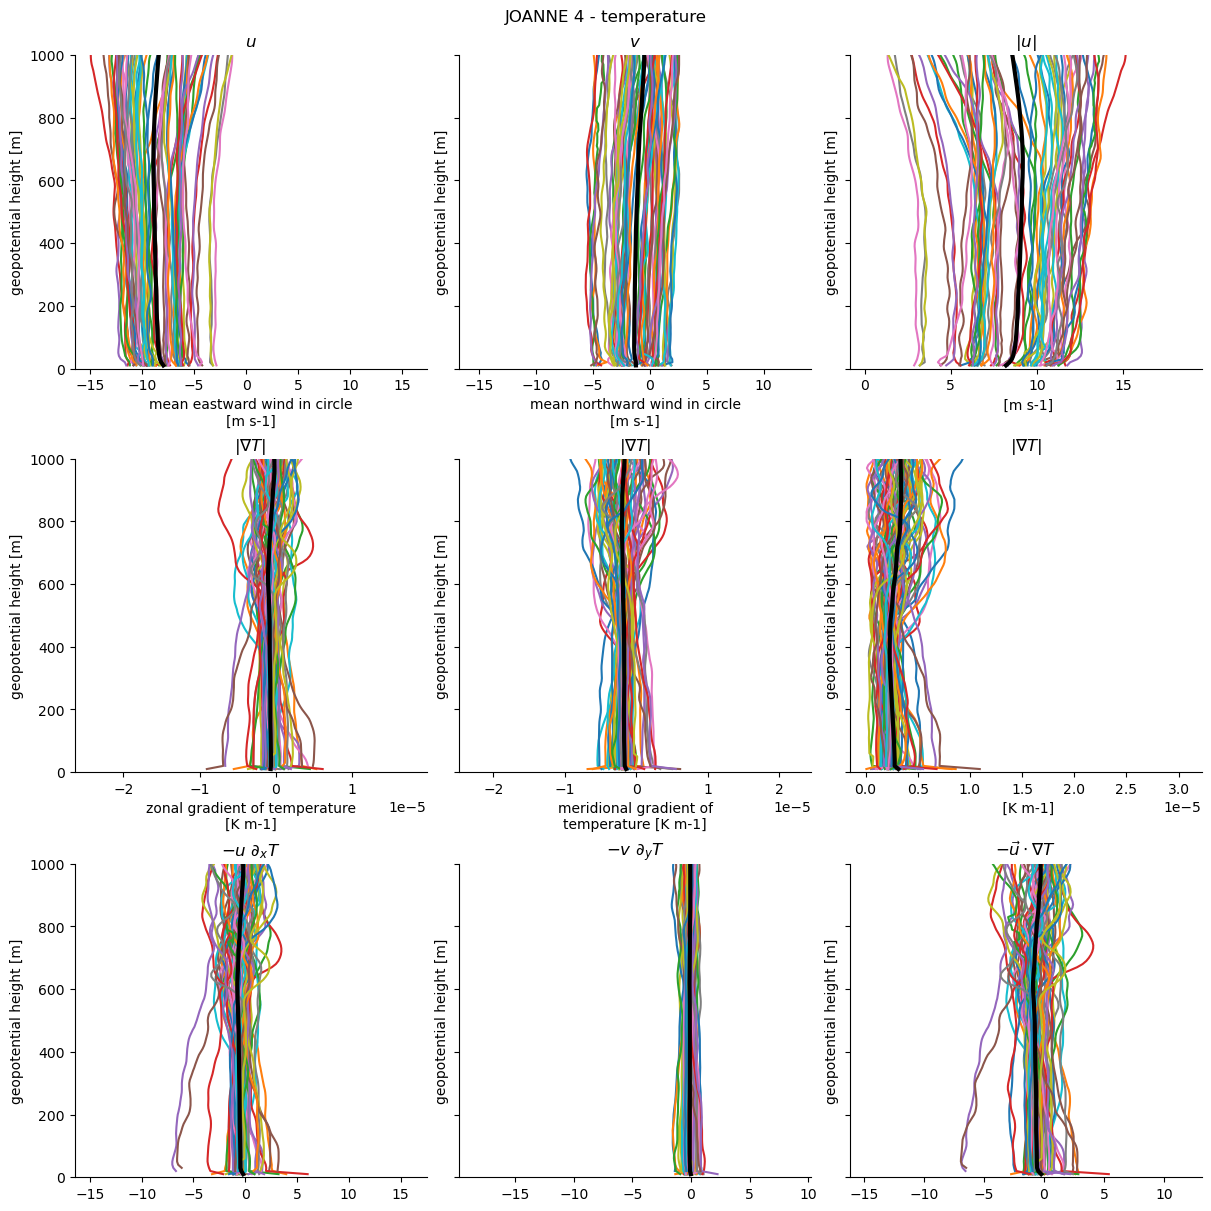

In [12]:
fig, ax = plt.subplots(3, 3, figsize=(12,12), sharey=True, constrained_layout=True)
fig.suptitle("JOANNE 4 - temperature")
ax=ax.flatten()
ax[0].set_ylim([0,1000])
per_day = 86400

(joanne4.u).plot.line(ax=ax[0], y="alt", add_legend=False)
(joanne4.u).mean(dim="circle").plot.line(ax=ax[0], y="alt", color="k", linewidth=3, add_legend=False)
ax[0].set_title(r"$u$")

(joanne4.v).plot.line(ax=ax[1], y="alt", add_legend=False)
(joanne4.v).mean(dim="circle").plot.line(ax=ax[1], y="alt", color="k", linewidth=3, add_legend=False)
ax[1].set_title(r"$v$")

((joanne4.u**2 + joanne4.v**2)**0.5).plot.line(ax=ax[2], y="alt", add_legend=False)
((joanne4.u**2 + joanne4.v**2)**0.5).mean(dim="circle").plot.line(ax=ax[2], y="alt", color="k", linewidth=3, add_legend=False)
ax[2].set_title(r"$|u|$")




(joanne4.dtadx).plot.line(ax=ax[3], y="alt", add_legend=False)
(joanne4.dtadx).mean(dim="circle").plot.line(ax=ax[3], y="alt", color="k", linewidth=3, add_legend=False)
ax[3].set_title(r"$|\nabla T|$")

(joanne4.dtady).plot.line(ax=ax[4], y="alt", add_legend=False)
(joanne4.dtady).mean(dim="circle").plot.line(ax=ax[4], y="alt", color="k", linewidth=3, add_legend=False)
ax[4].set_title(r"$|\nabla T|$")

((joanne4.dtadx**2 + joanne4.dtady**2)**0.5).plot.line(ax=ax[5], y="alt", add_legend=False)
((joanne4.dtadx**2 + joanne4.dtady**2)**0.5).mean(dim="circle").plot.line(ax=ax[5], y="alt", color="k", linewidth=3, add_legend=False)
ax[5].set_title(r"$|\nabla T|$")




(per_day*(- joanne4.u * joanne4.dtadx)).plot.line(ax=ax[6], y="alt", add_legend=False)
(per_day*(- joanne4.u * joanne4.dtadx)).mean(dim="circle").plot.line(ax=ax[6], y="alt", color="k", linewidth=3, add_legend=False)
ax[6].set_title(r"$-u~\partial_x T$")

(per_day*(- joanne4.v * joanne4.dtady)).plot.line(ax=ax[7], y="alt", add_legend=False)
(per_day*(- joanne4.v * joanne4.dtady)).mean(dim="circle").plot.line(ax=ax[7], y="alt", color="k", linewidth=3, add_legend=False)
ax[7].set_title(r"$-v~\partial_y T$")

(per_day*(- joanne4.u * joanne4.dtadx - joanne4.v * joanne4.dtady)).plot.line(ax=ax[8], y="alt", add_legend=False)
(per_day*(- joanne4.u * joanne4.dtadx - joanne4.v * joanne4.dtady)).mean(dim="circle").plot.line(ax=ax[8], y="alt", color="k", linewidth=3, add_legend=False)
ax[8].set_title(r"$-\vec{u}\cdot\nabla T$")


for x in ax:
    for spine in ["right", 'top']:
        x.spines[spine].set_visible(False)

plt.show()

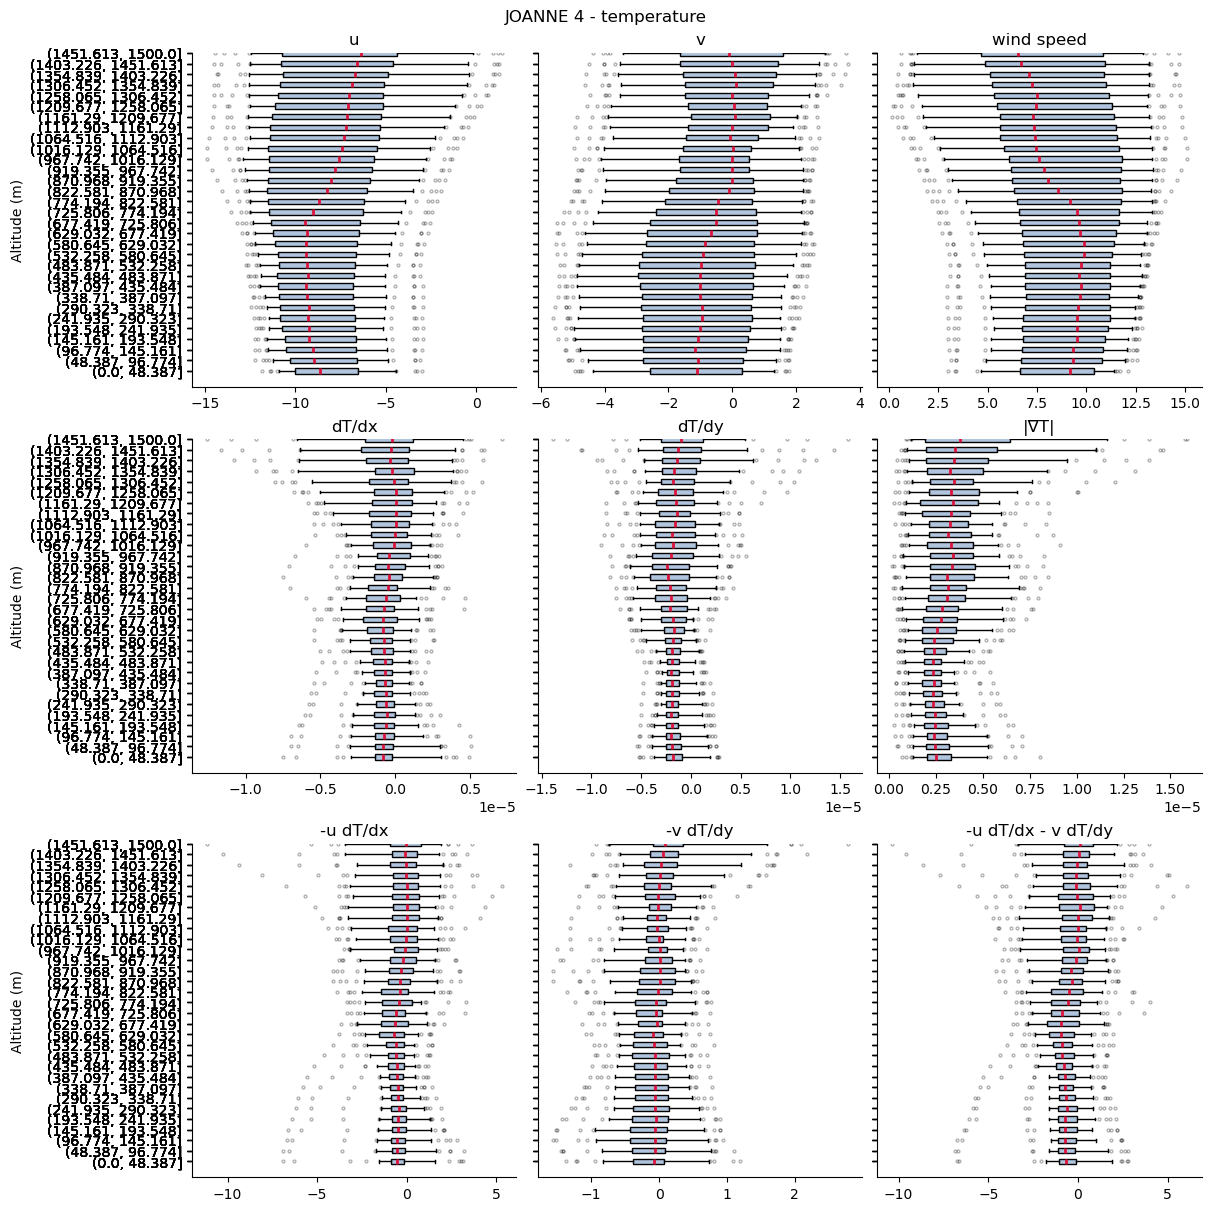

In [13]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(
    3, 3,
    figsize=(12, 12),
    sharey=True,
    constrained_layout=True
)

fig.suptitle("JOANNE 4 - temperature")
ax = ax.flatten()

per_day = 86400
alt_sel = slice(0, 1500)

# 15 altitude bins between 0 and 1500 m
bins = np.linspace(0, 1500, 32)

for a in ax:
    a.set_ylim(-0.5, 31)

# Variables to plot
variables = [
    joanne4.u,
    joanne4.v,
    (joanne4.u**2 + joanne4.v**2)**0.5,
    joanne4.dtadx,
    joanne4.dtady,
    (joanne4.dtadx**2 + joanne4.dtady**2)**0.5,
    per_day * (-joanne4.u * joanne4.dtadx),
    per_day * (-joanne4.v * joanne4.dtady),
    per_day * (-joanne4.u * joanne4.dtadx - joanne4.v * joanne4.dtady),
]

# Titles
titles = [
    "u",
    "v",
    "wind speed",
    "dT/dx",
    "dT/dy",
    "|∇T|",
    "-u dT/dx",
    "-v dT/dy",
    "-u dT/dx - v dT/dy",
]

for a, var, title in zip(ax, variables, titles):

    df = (
        var
        .sel(alt=alt_sel)
        .groupby_bins("alt", bins=bins)
        .mean(dim="alt")
        .to_pandas()
    )

    df.boxplot(
        ax=a,
        vert=False,
        whis=(5, 95),
        patch_artist=True,
        boxprops=dict(
            facecolor="lightsteelblue",
            edgecolor="k"
        ),
        medianprops=dict(
            color="crimson",
            linewidth=2
        ),
        whiskerprops=dict(color="k"),
        capprops=dict(color="k"),
        flierprops=dict(
            marker="o",
            markersize=2,
            alpha=0.3
        ),
    )

    a.set_title(title)
    a.set_xlabel("")
    a.grid(False)  # (axis="x", alpha=0.2)

    for spine in ["right", 'top']:
        a.spines[spine].set_visible(False)

# Altitude labels only on the left column
for a in ax[::3]:
    a.set_ylabel("Altitude (m)")



plt.show()


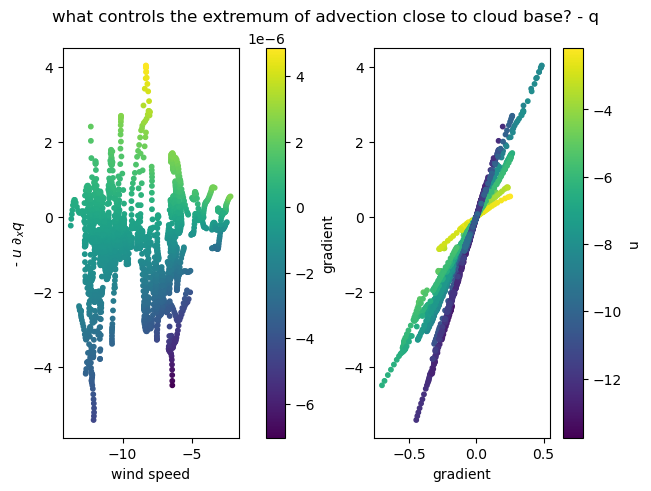

In [14]:
fig, ax = plt.subplots(1, 2, constrained_layout=True)
fig.suptitle("what controls the extremum of advection close to cloud base? - q")
per100km = 1e5
per_day = 86400

gr = (joanne4.dtadx).sel(alt=slice(500, 800))
x = (joanne4.u).sel(alt=slice(500, 800))
y = (- joanne4.u * per100km*joanne4.dtadx).sel(alt=slice(500, 800))

sc = ax[0].scatter( x, y, marker="o", c=gr, s=10 ) 
ax[0].set_xlabel("wind speed")
ax[0].set_ylabel(r"- $u~\partial_x q$")

fig.colorbar(sc, ax=ax[0], label="gradient")




u = joanne4.u.sel(alt=slice(500, 800))
x = (per100km*joanne4.dtadx).sel(alt=slice(500, 800))
y = (- joanne4.u * per100km*joanne4.dtadx).sel(alt=slice(500, 800))

sc = ax[1].scatter( x, y, marker="o",   c=u, s=10 ) 
ax[1].set_xlabel("gradient")

fig.colorbar(sc, ax=ax[1], label="u")

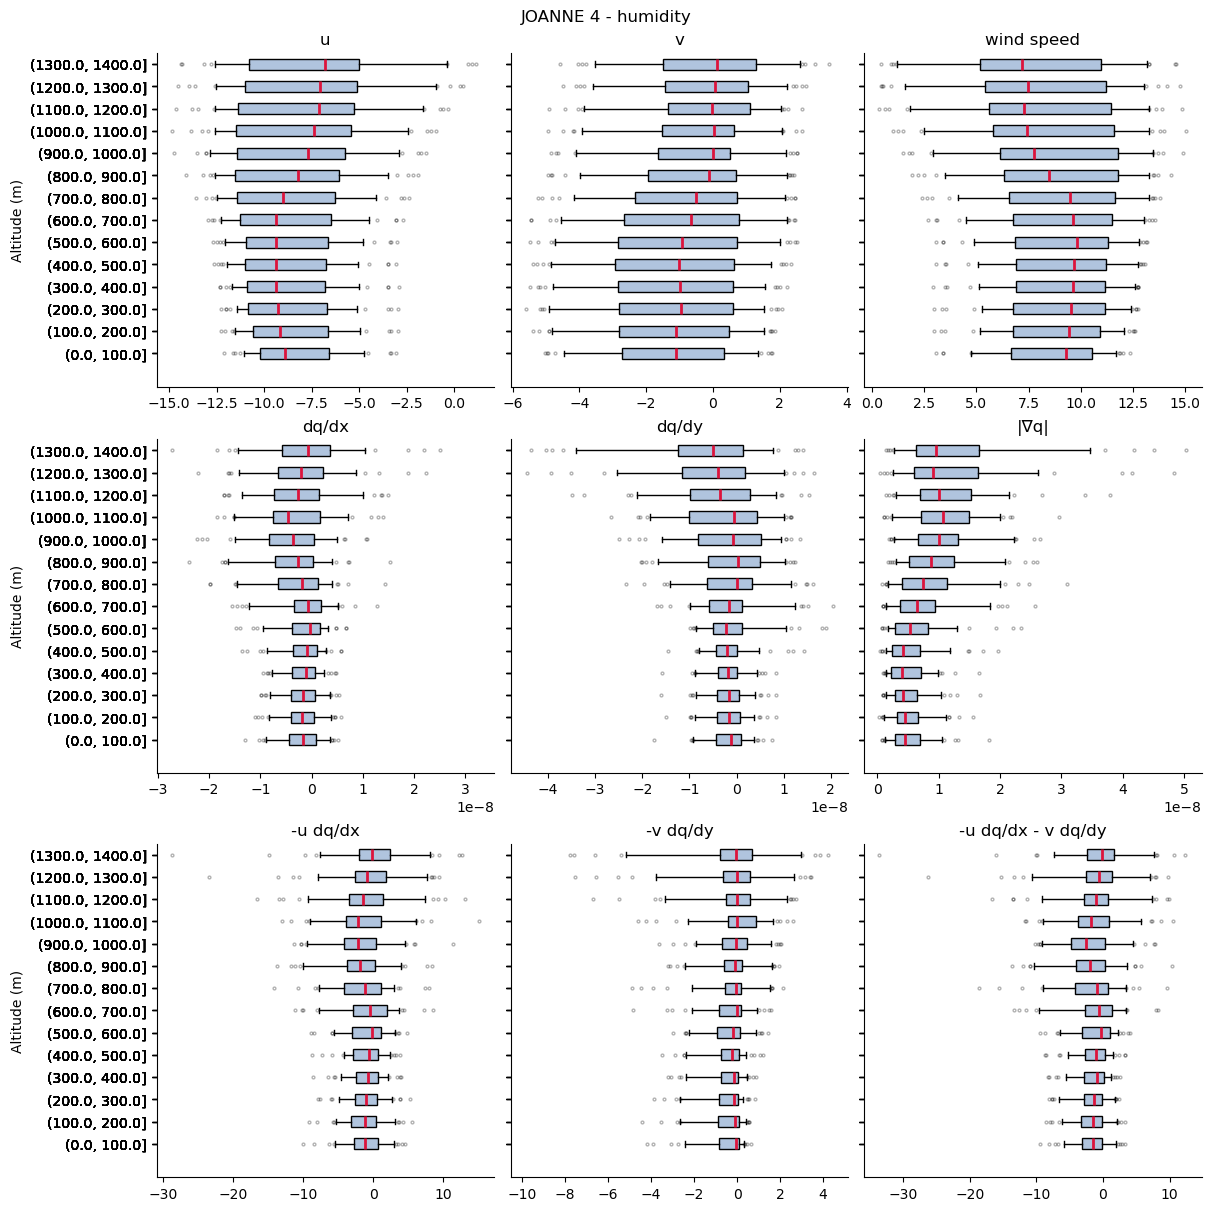

In [15]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(
    3, 3,
    figsize=(12, 12),
    sharey=True,
    constrained_layout=True
)

fig.suptitle("JOANNE 4 - humidity")
ax = ax.flatten()

per_day = 1000 * 86400
alt_sel = slice(0, 1500)

# 15 altitude bins between 0 and 1500 m
bins = np.linspace(0, 1500, 16)

for a in ax:
    a.set_ylim(-0.5, 14.5)

# Variables to plot
variables = [
    joanne4.u,
    joanne4.v,
    (joanne4.u**2 + joanne4.v**2)**0.5,
    joanne4.dqdx,
    joanne4.dqdy,
    (joanne4.dqdx**2 + joanne4.dqdy**2)**0.5,
    per_day * (-joanne4.u * joanne4.dqdx),
    per_day * (-joanne4.v * joanne4.dqdy),
    per_day * (-joanne4.u * joanne4.dqdx - joanne4.v * joanne4.dqdy),
]

# Titles
titles = [
    "u",
    "v",
    "wind speed",
    "dq/dx",
    "dq/dy",
    "|∇q|",
    "-u dq/dx",
    "-v dq/dy",
    "-u dq/dx - v dq/dy",
]

for a, var, title in zip(ax, variables, titles):

    df = (
        var
        .sel(alt=alt_sel)
        .groupby_bins("alt", bins=bins)
        .mean(dim="alt")
        .to_pandas()
    )

    df.boxplot(
        ax=a,
        vert=False,
        whis=(5, 95),
        patch_artist=True,
        boxprops=dict(
            facecolor="lightsteelblue",
            edgecolor="k"
        ),
        medianprops=dict(
            color="crimson",
            linewidth=2
        ),
        whiskerprops=dict(color="k"),
        capprops=dict(color="k"),
        flierprops=dict(
            marker="o",
            markersize=2,
            alpha=0.3
        ),
    )

    a.set_title(title)
    a.set_xlabel("")
    a.grid(False)  # (axis="x", alpha=0.2)

    for spine in ["right", 'top']:
        a.spines[spine].set_visible(False)

# Altitude labels only on the left column
for a in ax[::3]:
    a.set_ylabel("Altitude (m)")



plt.show()


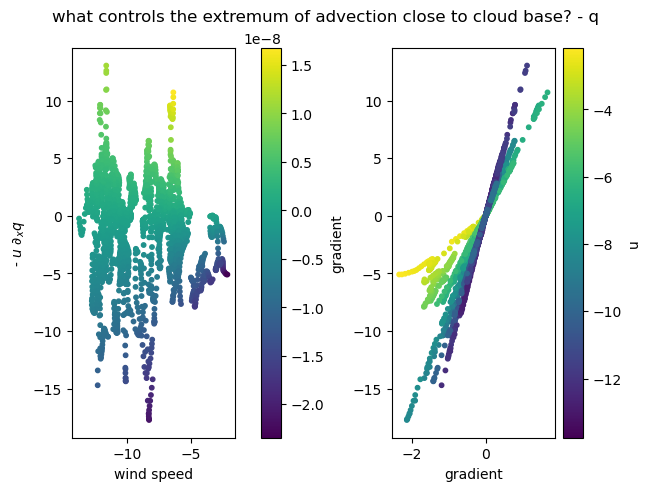

In [16]:
fig, ax = plt.subplots(1, 2, constrained_layout=True)
fig.suptitle("what controls the extremum of advection close to cloud base? - q")
gkg_per100km = 1000*1e5
per_day = 86400

gr = (joanne4.dqdx).sel(alt=slice(500, 800))
x = (joanne4.u).sel(alt=slice(500, 800))
y = (- joanne4.u * gkg_per100km*joanne4.dqdx).sel(alt=slice(500, 800))

sc = ax[0].scatter( x, y, marker="o", c=gr, s=10 ) 
ax[0].set_xlabel("wind speed")
ax[0].set_ylabel(r"- $u~\partial_x q$")

fig.colorbar(sc, ax=ax[0], label="gradient")




u = joanne4.u.sel(alt=slice(500, 800))
x = (gkg_per100km*joanne4.dqdx).sel(alt=slice(500, 800))
y = (- joanne4.u * gkg_per100km*joanne4.dqdx).sel(alt=slice(500, 800))

sc = ax[1].scatter( x, y, marker="o",   c=u, s=10 ) 
ax[1].set_xlabel("gradient")

fig.colorbar(sc, ax=ax[1], label="u")

## building image for the retreat

In [17]:
tracks_path_loc = "/Users/alessandrostorer/Desktop/PhD/1st_yy/work/datasets/EUREC4A_tracks_HALO_v1.0.nc"
tracks_path = "/work/mh1498/m301248/TCO_data/EUREC4A_halo/EUREC4A_tracks_HALO_v1.0.nc"
halo_eu_tracks = xr.open_dataset(tracks_path_loc)

halo_or_tracks = xr.open_dataset("ipfs://bafybeias3h5uxtt4ky4d4gn6l6gxjqfkzbde5jlunya6g3umnkvn7xoyoe", engine="zarr")

In [18]:
import eurec4a

meta = eurec4a.get_flight_segments()
meta.keys()

segments = [{**s,
             "platform_id": platform_id,
             "flight_id": flight_id
            }
            for platform_id, flights in meta.items()
            for flight_id, flight in flights.items()
            for s in flight["segments"]
           ]

kinds = set(k for s in segments for k in s["kinds"])

segment_ids_by_kind = {kind: [segment["segment_id"]
                              for segment in segments
                              if kind in segment["kinds"]]
    for kind in kinds
}

halo_circles_id = [ id for id in segment_ids_by_kind["circle"] if 'HALO' in id]

circle_start_time = [ np.datetime64(segments[i]["start"]).astype('datetime64[ns]') for i in range(len(segments)) if segments[i]["segment_id"] in halo_circles_id ] 
circle_end_time = [ np.datetime64(segments[i]["end"]).astype('datetime64[ns]') for i in range(len(segments)) if segments[i]["segment_id"] in halo_circles_id ] 

In [19]:
joanne_lats_eu = [joanne3['lat'].sel(alt=20).where(  (joanne3.launch_time.values >= start)&(joanne3.launch_time.values <= end)  ) for start, end in zip(circle_start_time, circle_end_time)]
joanne_lats_eu = np.concatenate(joanne_lats_eu)

joanne_lons_eu = [joanne3['lon'].sel(alt=20).where(  (joanne3.launch_time.values >= start)&(joanne3.launch_time.values <= end)  ) for start, end in zip(circle_start_time, circle_end_time)]
joanne_lons_eu = np.concatenate(joanne_lons_eu)

In [20]:
import orcestra


meta = orcestra.get_flight_segments()
meta.keys()

segments = [{**s,
             "platform_id": platform_id,
             "flight_id": flight_id
            }
            for platform_id, flights in meta.items()
            for flight_id, flight in flights.items()
            for s in flight["segments"]
           ]

kinds = set(k for s in segments for k in s["kinds"])

segment_ids_by_kind = {kind: [segment["segment_id"]
                              for segment in segments
                              if kind in segment["kinds"]]
    for kind in kinds
}

halo_circles_id = [ id for id in segment_ids_by_kind["circle"] if 'HALO' in id]

circle_start_time_or = [ np.datetime64(segments[i]["start"]).astype('datetime64[ns]') for i in range(len(segments)) if segments[i]["segment_id"] in halo_circles_id ] 
circle_end_time_or = [ np.datetime64(segments[i]["end"]).astype('datetime64[ns]') for i in range(len(segments)) if segments[i]["segment_id"] in halo_circles_id ] 

In [21]:
beach_lats_eu = [beach3['lat'].sel(altitude=20).where(  (beach3.launch_time.values >= start)&(beach3.launch_time.values <= end)  ) for start, end in zip(circle_start_time_or, circle_end_time_or)]
beach_lats_eu = np.concatenate(beach_lats_eu)

beach_lons_eu = [beach3['lon'].sel(altitude=20).where(  (beach3.launch_time.values >= start)&(beach3.launch_time.values <= end)  ) for start, end in zip(circle_start_time_or, circle_end_time_or)]
beach_lons_eu = np.concatenate(beach_lons_eu)

In [22]:
lats_eu = [halo_eu_tracks.lat.sel(time=slice(start, end)).values for start, end in zip(circle_start_time, circle_end_time)]
# lats_eu = np.concatenate(lats_eu)

lons_eu = [halo_eu_tracks.lon.sel(time=slice(start, end)).values for start, end in zip(circle_start_time, circle_end_time)]
# lons_eu = np.concatenate(lons_eu)


lats_or = [halo_or_tracks.lat.sel(time=slice(start, end)).values for start, end in zip(circle_start_time_or, circle_end_time_or)]
# lats_or = np.concatenate(lats_or)

lons_or = [halo_or_tracks.lon.sel(time=slice(start, end)).values for start, end in zip(circle_start_time_or, circle_end_time_or)]
# lons_or = np.concatenate(lons_or)


compute a certain statistic of the gradients in EU, so as to fit in the map plot

In [23]:
def assign_direction_magnitude(x, y, colors):
    # angle = np.arctan2(y, x)

    # Quadrant: 1, 2, 3, 4
    quadrant = np.where(
        (x >= 0) & (y >= 0), 1,
        np.where(
            (x < 0) & (y >= 0), 2,
            np.where((x < 0) & (y < 0), 3, 4)
        )
    )

    magnitude = np.sqrt(x**2 + y**2)

    if np.ndim(quadrant) == 0:
        point_colors = colors[int(quadrant) - 1]
        s=500.
    else:
        point_colors = [colors[q - 1] for q in quadrant]
        s = 2500* ( magnitude - np.min(magnitude) ) / ( np.max(magnitude) - np.min(magnitude) )

    angle = np.atan2(y, x)
    

    return angle, point_colors, s



blue_colors = [
    "#DCEEFF",  # very light
    "#91C4F2",
    "#3A86D1",
    "#0057A8"   # dark
]
orange_colors = [
    "#FFE5CC",  # very light
    "#FFB366",
    "#F47C20",
    "#C44E00"   # dark
]


angle_eu, dir_eu, s_eu = assign_direction_magnitude( joanne4.dqdx.sel(alt=300.).mean(dim="circle", skipna=True), joanne4.dqdy.sel(alt=300.).mean(dim="circle", skipna=True), orange_colors )
angle_or, dir_or, s_or = assign_direction_magnitude( beach4.q_dqdx.sel(altitude=300.), beach4.q_dqdy.sel(altitude=300.), blue_colors )



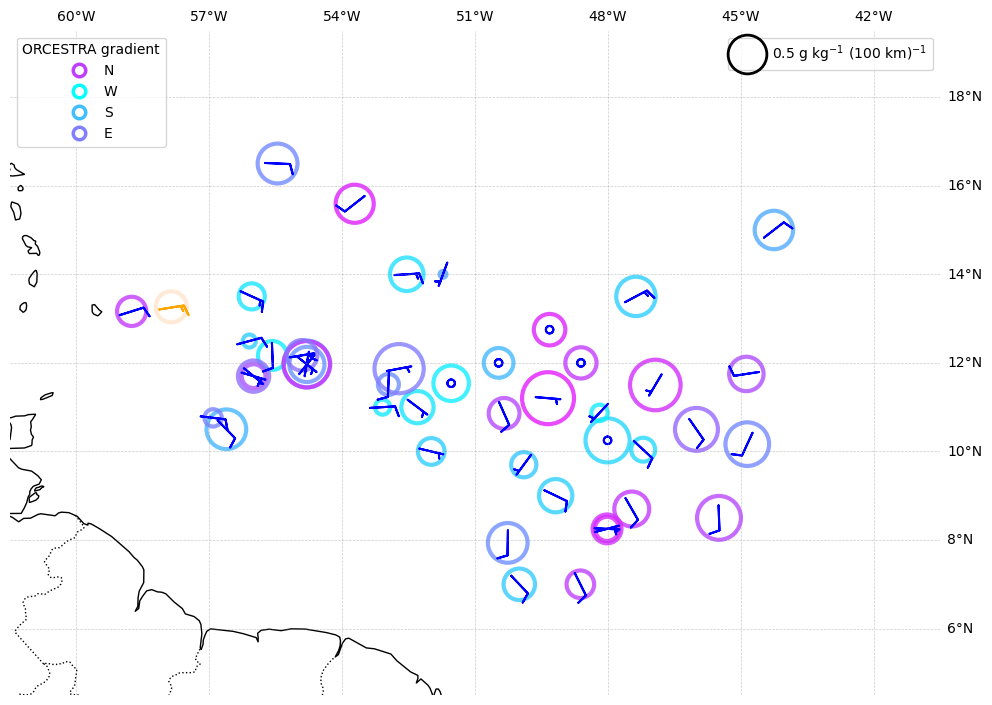

In [25]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.lines import Line2D

fig, ax = plt.subplots(
    figsize=(12, 12),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

mask_main_eu_circle = (joanne4.circle_lon.values <= -57)&(joanne4.circle_lon.values >= -60)


#### flights
# for lon, lat in zip(lons_eu, lats_eu):
#     ax.plot(lon[::20], lat[::20], 
#             "orange", alpha=0.3, transform=ccrs.PlateCarree(), linewidth=1.
#             )

# for lon, lat in zip(lons_or, lats_or):
#     ax.plot(lon[::20], lat[::20], 
#             "blue", alpha=0.15, transform=ccrs.PlateCarree(), linewidth=1.
#                 )



#### dropsondes
# pos = ax.scatter(joanne_lons_eu[::5],
#                  joanne_lats_eu[::5], 
#                  c="red", transform=ccrs.PlateCarree(), s=1.5
#                  )
# pos = ax.scatter(beach_lons_eu,
#                  beach_lats_eu, 
#                  c="green", transform=ccrs.PlateCarree(), s=1.5
#                  )


#### zonal gradients
norm = plt.Normalize(vmin=-np.pi, vmax=np.pi)
cmap = plt.cm.Oranges

ax.scatter(
    joanne4.circle_lon.values[mask_main_eu_circle][0],
    joanne4.circle_lat.values[mask_main_eu_circle][0],
    facecolors="none",
    edgecolors=cmap(plt.Normalize(vmin=-np.pi, vmax=np.pi)(angle_eu)),
    s=s_eu,
    linewidth=3,
    alpha=0.8
)
grad_legend_handles_eu = [
    Line2D(
        [0], [0],
        marker='o',
        linestyle='',
        markerfacecolor='none',
        markeredgecolor=cmap(norm(angle)),
        markeredgewidth=2.5,
        markersize=9,
        label=label
    )
    for angle, label in [
            (np.pi / 2, "N"),
            ( -np.pi, "W"),
            ( - np.pi / 2 , "S"),
            (0, "E"),
        ]
]

norm = plt.Normalize(vmin=-np.pi, vmax=np.pi)
cmap = plt.cm.cool
ax.scatter(
    beach4.circle_lon.values,
    beach4.circle_lat.values,
    facecolors="none",
    edgecolors=cmap(plt.Normalize(vmin=-np.pi, vmax=np.pi)(angle_or)),
    s=s_or,
    linewidth=3,
    alpha=0.8
)

grad_legend_handles_or = [
    Line2D(
        [0], [0],
        marker='o',
        linestyle='',
        markerfacecolor='none',
        markeredgecolor=cmap(norm(angle)),
        markeredgewidth=2.5,
        markersize=9,
        label=label
    )
    for angle, label in [
            (np.pi / 2, "N"),
            ( -np.pi, "W"),
            ( - np.pi / 2 , "S"),
            (0, "E"),
        ]

    # for angle, label in [
    #     (np.pi / 4, "NE"),
    #     (3 * np.pi / 4, "NW"),
    #     (7 * np.pi / 4, "SE"),
    #     (11 * np.pi / 4, "SW"),
    # ]
]






## eurec4a wind
max_magnitude = max(  ((joanne4.u**2+joanne4.v**2)**(0.5)).sel(alt=slice(20,100)).mean(dim=["alt"]).max().values, 
                      ((beach4.u_mean**2+beach4.v_mean**2)**(0.5)).sel(altitude=slice(20,100)).mean(dim=["altitude"]).max().values )

plt.barbs(joanne4.circle_lon.values[mask_main_eu_circle][0], 
           joanne4.circle_lat.values[mask_main_eu_circle][0], 
           (joanne4.u).sel(alt=slice(20,100)).mean(dim=["alt", "circle"]).values*1.94,
           (joanne4.v).sel(alt=slice(20,100)).mean(dim=["alt", "circle"]).values*1.94, 
             color="orange",
            length=6,  # Adjust barb length
            linewidth=1.5,
            pivot="middle"    )

# plt.barbs(joanne4.circle_lon.values[~mask_main_eu_circle], 
#            joanne4.circle_lat.values[~mask_main_eu_circle], 
#            (joanne4.u).sel(alt=slice(20,100)).mean(dim=["alt"]).values[~mask_main_eu_circle]*1.94,
#            (joanne4.v).sel(alt=slice(20,100)).mean(dim=["alt"]).values[~mask_main_eu_circle]*1.94, 
#              color="orange",
#             length=6,  # Adjust barb length
#             linewidth=1.5,
#             pivot="middle"    )

## orcestra wind
plt.barbs(beach4.circle_lon.values, 
           beach4.circle_lat.values, 
           (beach4.u_mean).sel(altitude=slice(20,100)).mean(dim=["altitude"]).values*1.94,
           (beach4.v_mean).sel(altitude=slice(20,100)).mean(dim=["altitude"]).values*1.94 ,
            color="blue",
            length=6,  # Adjust barb length
            linewidth=1.5,
            pivot="middle"     )




ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')


ax.set_extent([
    -59 - 2.5,
    -59 + 18.5,
    13 - 8.5,
    13 + 6.5
], crs=ccrs.PlateCarree())


# Configure gridlines
gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.5,
    color='gray',
    alpha=0.4,
    linestyle='--'
)

# Move labels to top and right
gl.bottom_labels = False  # Disable bottom labels
gl.left_labels = False    # Disable left labels
gl.top_labels = True      # Enable top labels
gl.right_labels = True    # Enable right labels

# Style the labels
gl.xlabel_style = {'size': 10}
gl.ylabel_style = {'size': 10}

ax.set_frame_on(False)



## color legends for gradient direction

# Create legend handles
blue_handles = [
    Line2D([0], [0], marker='o', linestyle='',
           markerfacecolor=c, markeredgecolor='none',
           markersize=8, label=f"Direction {i+1}")
    for i, c in enumerate(blue_colors)
]

orange_handles = [
    Line2D([0], [0], marker='o', linestyle='',
           markerfacecolor=c, markeredgecolor='none',
           markersize=8, label=f"Direction {i+1}")
    for i, c in enumerate(orange_colors)
]

# # First legend
# legend_blue = ax.legend(
#     handles=blue_handles,
#     title="Blue directions",
#     loc="upper left"
# )

legend_blue = ax.legend(
    handles=grad_legend_handles_or,
    title="ORCESTRA gradient",
    loc="upper left"
)

# Add it without replacing it with the second legend
ax.add_artist(legend_blue)

# Second legend
# legend_orange = ax.legend(
#     handles=orange_handles,
#     title="Orange directions",
#     loc="upper right"
# )
legend_orange = ax.legend(
    handles=grad_legend_handles_eu,
    title="EUREC4A gradient",
    loc="upper right"
)



## ring dimension legend
from matplotlib.lines import Line2D

ref_magnitude = 0.5 / (1000*100000)  # choose the magnitude you want to represent
magnitude_or = np.sqrt( beach4.q_dqdx.sel(altitude=300.)**2 + beach4.q_dqdy.sel(altitude=300.)**2 )

marker_size = 2500 * (
    ref_magnitude - np.min(magnitude_or)
) / (
    np.max(magnitude_or) - np.min(magnitude_or)
)

size_handle = Line2D(
    [0], [0],
    marker='o',
    linestyle='',
    markerfacecolor='none',
    markeredgecolor='black',
    markeredgewidth=2,
    markersize=np.sqrt(marker_size),
    label=f"{ref_magnitude * 1000*100000:g}" + r" $\rm g~kg^{-1}~(100~km)^{-1}$"
)

ax.legend(
    handles=[size_handle],
    loc="upper right"
)


plt.show()

(array([0.47813219, 1.01118496, 1.77361184, 1.59915843, 1.29871014,
        0.8851905 , 0.63320229, 0.3779828 , 0.22614356, 0.23583555,
        0.0678431 , 0.02907559, 0.03553686, 0.01938374, 0.01938372,
        0.        , 0.        , 0.00323062, 0.        , 0.00323062,
        0.        , 0.00323062, 0.00323062, 0.        , 0.00323062,
        0.        , 0.00323062, 0.        , 0.        , 0.00323062]),
 array([2.67073698e-03, 1.17441900e-01, 2.32213065e-01, 3.46984237e-01,
        4.61755395e-01, 5.76526582e-01, 6.91297770e-01, 8.06068897e-01,
        9.20840085e-01, 1.03561127e+00, 1.15038240e+00, 1.26515353e+00,
        1.37992477e+00, 1.49469590e+00, 1.60946703e+00, 1.72423828e+00,
        1.83900940e+00, 1.95378053e+00, 2.06855178e+00, 2.18332291e+00,
        2.29809403e+00, 2.41286516e+00, 2.52763629e+00, 2.64240766e+00,
        2.75717878e+00, 2.87194991e+00, 2.98672104e+00, 3.10149217e+00,
        3.21626329e+00, 3.33103466e+00, 3.44580579e+00]),
 [<matplotlib.patches.Polygo

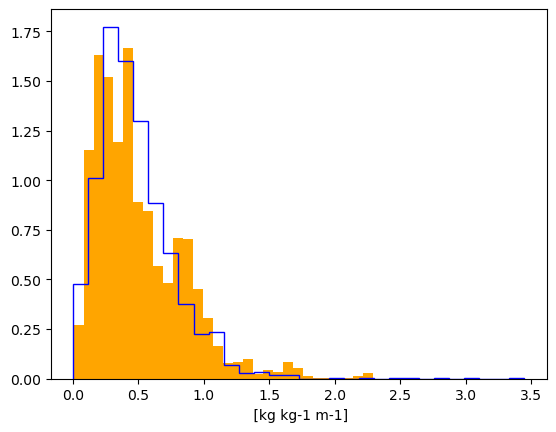

In [26]:
(np.sqrt( joanne4.dqdx.sel(alt=slice(200,500))**2 + joanne4.dqdy.sel(alt=slice(200,500))**2 ) * 1000 * 100000).plot.hist(bins=30, color="orange", density=True)
(np.sqrt( beach4.q_dqdx.sel(altitude=slice(200,500))**2 + beach4.q_dqdy.sel(altitude=slice(200,500))**2 ) * 1000 * 100000).plot.hist(bins=30, color="blue", histtype="step", density=True)